<a href="https://colab.research.google.com/github/KrishGuptareal/Team11_Project_ai/blob/main/Notebooks/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Roadmap - Action Plan**
---
## Data Cleaning - Preprocessing
- Load dataset, check nulls, check class distribution
- Generate rating distribution plot and summary stats
- Text cleaning (lowercase, remove noise, tokenize)
- Derive sentiment labels from ratings (e.g. 1–2 = neg, 4–5 = pos)
- Research about algorithms and make comparative study table
## Modelling
- TF-IDF vectorisation, train/test split
- Implement chosen classifier (Logistic / SVM / LSTM) for sentiment analysis (Task 1)
- Evaluation — accuracy, F1, confusion matrix
- Hyperparameter tuning for Task 1 model
- Implement chosen regressor (Ridge / RF / XGBoost) for rating prediction (Task 2)
- Evaluation — RMSE, MAE, R²
- Hyperparameter tuning for Task 2 model
## Analysis
- Error analysis: pull misclassified examples, find patterns
- Cross analysis: where sentiment label and predicted rating disagree
- Final comparative discussion: classification vs regression strengths
## Deliverables
- report
- presentation
- code clean up


In [1]:
import pandas as pd
import numpy as np
import nltk
import re
import html
import os
import pickle
import warnings
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import scipy.sparse as sp

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

warnings.filterwarnings('ignore')

OUTPUT_DIR = "preprocessed_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: ./{OUTPUT_DIR}/")

Outputs will be saved to: ./preprocessed_outputs/


#**Data Analysis**


In [2]:
df = pd.read_csv('recipe_reviews.csv')
print(f"Dataset shape: {df.shape}")
df.head(2)

Dataset shape: (18182, 15)


,Unnamed: 0,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...


In [3]:
print("Basic Info")
print(df.info())
print()
print("Missing values")
print(df.isnull().sum())

# Rating counts
star_counts = df['stars'].value_counts().sort_index()
print()
print("Star Rating Distribution")
print(star_counts)

# mean and std
print()
print(f"Average rating: {df['stars'].mean():.3f}  |  Std dev: {df['stars'].std():.3f}")
print()

# unique users and items
if 'user_id' in df.columns and 'recipe_name' in df.columns:
    n_users = df['user_id'].nunique()
    n_items = df['recipe_name'].nunique()
    print(f"Unique reviewers: {n_users:,}  |  Unique items: {n_items:,}")

Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18182 entries, 0 to 18181
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       18182 non-null  int64 
 1   recipe_number    18182 non-null  int64 
 2   recipe_code      18182 non-null  int64 
 3   recipe_name      18182 non-null  object
 4   comment_id       18182 non-null  object
 5   user_id          18182 non-null  object
 6   user_name        18182 non-null  object
 7   user_reputation  18182 non-null  int64 
 8   created_at       18182 non-null  int64 
 9   reply_count      18182 non-null  int64 
 10  thumbs_up        18182 non-null  int64 
 11  thumbs_down      18182 non-null  int64 
 12  stars            18182 non-null  int64 
 13  best_score       18182 non-null  int64 
 14  text             18180 non-null  object
dtypes: int64(10), object(5)
memory usage: 2.1+ MB
None

Missing values
Unnamed: 0         0
recipe_number      0
r

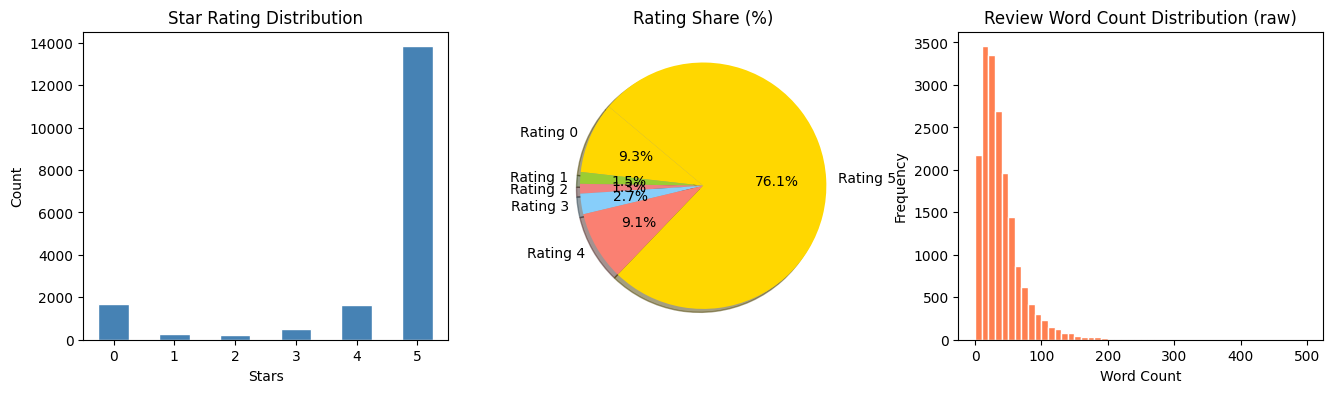

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart
star_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Star Rating Distribution')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
labels = [f'Rating {i}' for i in star_counts.index]
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'salmon']
axes[1].pie(
    star_counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=140
)
axes[1].set_title('Rating Share (%)')

# Review word count histogram
df['raw_length'] = df['text'].fillna('').apply(lambda x: len(x.split()))
axes[2].hist(df['raw_length'].clip(upper=500), bins=50, color='coral', edgecolor='white')
axes[2].set_title('Review Word Count Distribution (raw)')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')

plt.show()

#**Data Cleaning and Preprocessing**

In [5]:
def map_sentiment(stars):
    if stars <= 2:
        return 0   # Negative
    elif stars >= 4:
        return 1   # Positive
    else:
        return None  # Drop 3-star

df['sentiment'] = df['stars'].apply(map_sentiment)
df = df.dropna(subset=['sentiment'])
df['sentiment'] = df['sentiment'].astype(int)

label_names = {0: 'Negative', 1: 'Positive'}

print("Sentiment Distribution (after dropping neutrals)")
s = df['sentiment'].value_counts().sort_index()
for k, v in s.items():
    print(f"{label_names[k]:10s} (class {k}): {v:,}  ({v/len(df)*100:.1f}%)")

Sentiment Distribution (after dropping neutrals)
Negative   (class 0): 2,208  (12.5%)
Positive   (class 1): 15,484  (87.5%)


In [6]:
df.head(2)

,Unnamed: 0,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text,raw_length,sentiment
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ...",67,1
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...,27,1


In [7]:
STOPWORDS = set(stopwords.words('english')) - {'no', 'not', 'nor', 'neither', 'never', 'nothing'}
lemmatizer = WordNetLemmatizer()
def clean_text(text: str):
    if not isinstance(text, str):
        return None

    text = html.unescape(text)                      # decode HTML entities
    text = text.lower()                             # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)      # strip URLs
    text = re.sub(r'[^a-z\s]', '', text)            # keep only a–z and whitespace
    text = re.sub(r'\s+', ' ', text).strip()        # collapse whitespace

    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]   # stopword removal
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # lemmatization

    text = ' '.join(tokens)

    return text if text else None


df['clean_text'] = df['text'].apply(clean_text)

before = len(df)
df = df.dropna(subset=['clean_text'])
df = df[df['clean_text'].str.strip() != '']
dropped = before - len(df)

df['token_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print(f"Rows dropped (empty/null text) : {dropped}")
print(f"Rows remaining                 : {len(df):,}")
print(f"Avg tokens/review              : {df['token_count'].mean():.1f}")
print(f"Min / Max tokens               : {df['token_count'].min()} / {df['token_count'].max()}")

Rows dropped (empty/null text) : 21
Rows remaining                 : 17,671
Avg tokens/review              : 19.6
Min / Max tokens               : 1 / 262


In [8]:
preview = df[['text', 'clean_text', 'stars', 'sentiment']].head(5).copy()
preview.columns = ['Before (raw)', 'After (cleaned)', 'Stars', 'Sentiment']
preview['Before (raw)'] = preview['Before (raw)'].str[:120] + '...'
preview['After (cleaned)'] = preview['After (cleaned)'].str[:120] + '...'
print(preview.to_string(index=False))

                                                                                                               Before (raw)                                                                                                             After (cleaned)  Stars  Sentiment
I tweaked it a little, removed onions because of onion haters in my house, used Italian seasoning instead of just oregan... tweaked little removed onion onion hater house used italian seasoning instead oregano use paprika cayenne mix little rec...      5          1
Bush used to have a white chili bean and it made this recipe super simple. I’ve written to them and asked them to please...                                  bush used white chili bean made recipe super simple ive written asked please bring back...      5          1
I have a very complicated white chicken chili recipe that I have made for years. Everyone raves over it. I saw this reci... complicated white chicken chili recipe made year everyone raf saw recipe thoug

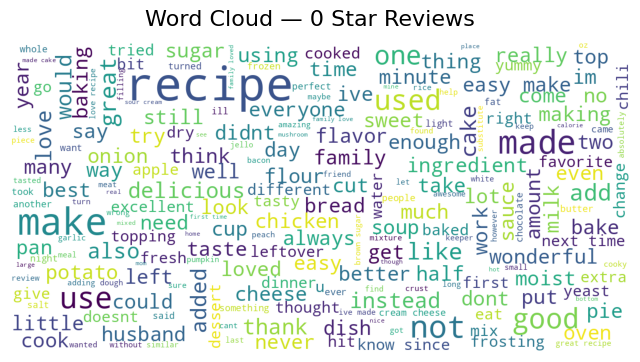

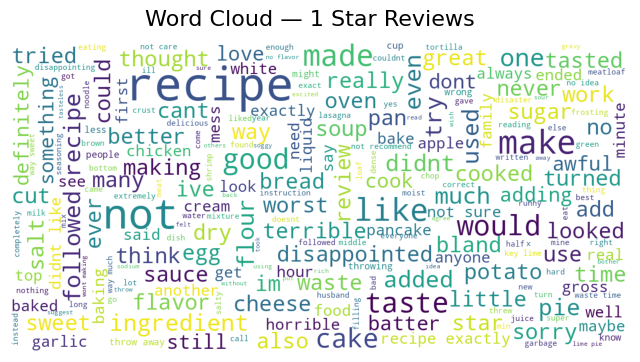

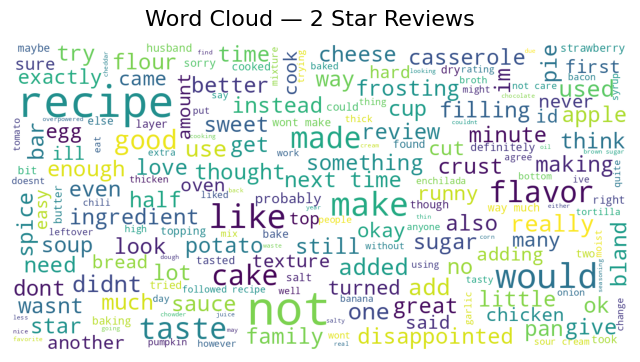

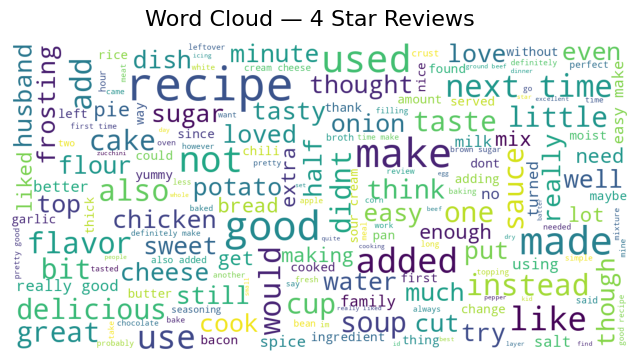

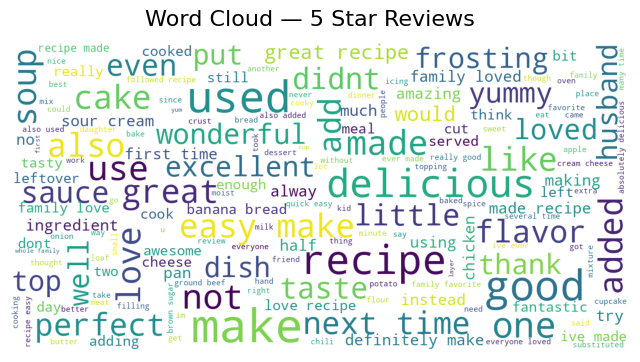

In [9]:
wc_stopwords = set(STOPWORDS)

def show_wordcloud(text_data, title=None):
    wc = WordCloud(
        background_color='white',
        stopwords=wc_stopwords,
        max_words=500,
        max_font_size=30,
        scale=3,
        random_state=1
    ).generate(str(text_data))

    fig = plt.figure(figsize=(8, 5))
    plt.axis('off')
    if title:
        fig.suptitle(title, fontsize=16)
        fig.subplots_adjust(top=1.1)
    plt.imshow(wc)
    plt.show()


# Group cleaned text by star rating
star_text = df.groupby('stars')['clean_text'].apply(lambda x: ' '.join(x))

for star in sorted(star_text.index):
    show_wordcloud(star_text[star], title=f"Word Cloud — {star} Star Reviews")
    print()

In [10]:
# Drop identifier columns
drop_columns = [c for c in [
    'Unnamed: 0', 'recipe_number', 'recipe_code',
    'comment_id', 'user_name', 'user_id', 'recipe_name'
] if c in df.columns]

df = df.drop(columns=drop_columns)

print(f"Dropped identifier columns: {drop_columns}")

# Optional feature: review length
df['review_length'] = df['clean_text'].str.split().str.len()
print()
print(f"DataFrame shape after preprocessing: {df.shape}")
df.head(2)

Dropped identifier columns: ['Unnamed: 0', 'recipe_number', 'recipe_code', 'comment_id', 'user_name', 'user_id', 'recipe_name']

DataFrame shape after preprocessing: (17671, 13)


,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text,raw_length,sentiment,clean_text,token_count,review_length
0,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ...",67,1,tweaked little removed onion onion hater house...,33,33
1,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...,27,1,bush used white chili bean made recipe super s...,15,15


In [11]:
target_cols = ['stars', 'sentiment']
X        = df.drop(columns=target_cols)
y_stars  = df['stars']
y_sent  = df['sentiment']

X_train, X_temp, y_stars_train, y_stars_temp, y_sent_train, y_sent_temp = train_test_split(
    X, y_stars, y_sent,
    test_size=0.30,
    stratify=y_sent,
    random_state=42
)

X_val, X_test, y_stars_val, y_stars_test, y_sent_val, y_sent_test = train_test_split(
    X_temp, y_stars_temp, y_sent_temp,
    test_size=0.50,
    stratify=y_sent_temp,
    random_state=42
)

print(f"train : {len(X_train):,}  |  val : {len(X_val):,}  |  test : {len(X_test):,}")

print("\nStars distribution across splits:")
for name, y in [('train', y_stars_train), ('val', y_stars_val), ('test', y_stars_test)]:
    dist = y.value_counts(normalize=True).sort_index()
    pcts = '  '.join([f"{k} star - {v*100:.1f}%" for k, v in dist.items()])
    print(f"  {name}: {pcts}")

print("\n3-Class Sentiment distribution across splits:")
for name, y in [('train', y_sent_train), ('val', y_sent_val), ('test', y_sent_test)]:
    dist = y.value_counts(normalize=True).sort_index()
    pcts = '  '.join([f"{label_names[k]} - {v*100:.1f}%" for k, v in dist.items()])
    print(f"  {name}: {pcts}")

train : 12,369  |  val : 2,651  |  test : 2,651

Stars distribution across splits:
  train: 0 star - 9.7%  1 star - 1.4%  2 star - 1.3%  4 star - 9.3%  5 star - 78.2%
  val: 0 star - 9.4%  1 star - 2.0%  2 star - 1.1%  4 star - 9.1%  5 star - 78.5%
  test: 0 star - 9.1%  1 star - 1.9%  2 star - 1.5%  4 star - 10.0%  5 star - 77.5%

3-Class Sentiment distribution across splits:
  train: Negative - 12.5%  Positive - 87.5%
  val: Negative - 12.5%  Positive - 87.5%
  test: Negative - 12.5%  Positive - 87.5%


In [12]:
X_train_text = X_train['clean_text']
X_val_text   = X_val['clean_text']
X_test_text  = X_test['clean_text']

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=20000,  # cap vocabulary size
    min_df=3,             # ignore very rare terms
    sublinear_tf=True,    # log scale TF gives less priority to very common terms
)

X_train_vec = vectorizer.fit_transform(X_train_text.fillna(''))
X_val_vec   = vectorizer.transform(X_val_text.fillna(''))
X_test_vec  = vectorizer.transform(X_test_text.fillna(''))

print(f"TF-IDF vocab size : {len(vectorizer.vocabulary_):,}")
print(f"Train matrix      : {X_train_vec.shape}")
print(f"Val matrix        : {X_val_vec.shape}")
print(f"Test matrix       : {X_test_vec.shape}")

TF-IDF vocab size : 17,459
Train matrix      : (12369, 17459)
Val matrix        : (2651, 17459)
Test matrix       : (2651, 17459)


In [13]:
sp.save_npz(f"{OUTPUT_DIR}/X_train.npz", X_train_vec)
sp.save_npz(f"{OUTPUT_DIR}/X_val.npz", X_val_vec)
sp.save_npz(f"{OUTPUT_DIR}/X_test.npz", X_test_vec)

with open(f"{OUTPUT_DIR}/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("── Final feature matrices ──")
print(f"  X_train : {X_train_vec.shape}")
print(f"  X_val   : {X_val_vec.shape}")
print(f"  X_test  : {X_test_vec.shape}")

── Final feature matrices ──
  X_train : (12369, 17459)
  X_val   : (2651, 17459)
  X_test  : (2651, 17459)


In [14]:
# Task 2: Rating Prediction (Regression)
y_stars_train.to_csv(f"{OUTPUT_DIR}/y_train_stars.csv", index=False)
y_stars_val.to_csv(  f"{OUTPUT_DIR}/y_val_stars.csv",   index=False)
y_stars_test.to_csv( f"{OUTPUT_DIR}/y_test_stars.csv",  index=False)
print("Task 2 (rating regression) targets saved.")

# Task 1: Sentiment Classification (3-class)
y_sent_train.to_csv(f"{OUTPUT_DIR}/y_train_sentiment.csv", index=False)
y_sent_val.to_csv(  f"{OUTPUT_DIR}/y_val_sentiment.csv",   index=False)
y_sent_test.to_csv( f"{OUTPUT_DIR}/y_test_sentiment.csv",  index=False)
print("Task 1 (3-class sentiment) targets saved.")

Task 2 (rating regression) targets saved.
Task 1 (3-class sentiment) targets saved.


In [15]:
# 3-class weights
classes = np.sort(y_sent_train.unique())
weights  = compute_class_weight(class_weight='balanced', classes=classes, y=y_sent_train)
class_weight = dict(zip(classes, weights))

print("Class weights — 3-class sentiment (balanced):")
for cls, w in sorted(class_weight.items()):
    print(f"  {label_names[cls]:10s} (class {cls}): weight={w:.3f}  (n={( y_sent_train == cls).sum():,})")

with open(f"{OUTPUT_DIR}/class_weights.pkl", 'wb') as f:
    pickle.dump(class_weight, f)

Class weights — 3-class sentiment (balanced):
  Negative   (class 0): weight=4.008  (n=1,543)
  Positive   (class 1): weight=0.571  (n=10,826)


#**Downloading files**



In [16]:
#Snippet for downloading the preprocessed folder
from google.colab import files
import shutil
shutil.make_archive('preprocessed_outputs', 'zip', 'preprocessed_outputs')
files.download('preprocessed_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from google.colab import drive
drive.mount('/content/drive')

shutil.copytree('preprocessed_outputs', '/content/drive/MyDrive/preprocessed_outputs', dirs_exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/preprocessed_outputs'